Dataset -- **Adult Income** The Adult Census dataset contains demographic information collected from the US Census Bureau, detailing various attributes such as age, education, work class, marital status, occupation, and income level (>50K or <=50K) for individuals. The dataset includes a mix of categorical and numerical features.Number of Attributes
6 continuous, 8 nominal attributes.

Link:https://www.kaggle.com/datasets/sagnikpatra/uci-adult-census-data-dataset


**Attribute Information:**
age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
sex: Female, Male.
capital-gain: continuous.
capital-loss: continuous.
hours-per-week: continuous.
native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.
class: >50K, <=50K


In [281]:
#importing necessary libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, classification_report, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [282]:
# Loading Dataset
df = pd.read_csv("C:/Users/HP/Downloads/archive (1)/adult.csv")# Loading the dataset

In [283]:
df. head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [284]:
df.shape # printing shape to get idea about no. of rows and columns, even though i have some background knowledge about dataset.

(32561, 15)

So we total have 48842 rows and 15 features

Attribute Information:

age: continuous.

workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

fnlwgt: continuous.

education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

education-num: continuous.

marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

sex: Female, Male.

capital-gain: continuous.

capital-loss: continuous.

hours-per-week: continuous.

native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia,El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands. class: >50K, <=50K we total have 32561 rows and 15 features




In [285]:
df.info() # it tell us about data type and if null value present of each column(feature)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


So from df.info() we get to know about features with their data type and if any null value presents in it. so we don't have any null value in this dataset.

In [286]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


So we don't have null value instead we have '?' in two columns that is workclass and occupation contains '?' so need to handle it

In [287]:
df.replace('?', np.nan, inplace = True) # Here we replace '?' with nan
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Now we can see that in index 4 instead of '?' it has replaced with nan value
Next check how many values is nan.

In [288]:
df.isnull().sum()/len(df)*100  # percentage of of null values present in each columns

age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
native.country    1.790486
income            0.000000
dtype: float64

The workclass and occupation has missing data around 5 %, however One thing i thing noticed that work class and ocuupation have same number of  null values,  as if the occupation is null then work class will also be null. so for that reason we have delete the missimg values, The native country percentage is also less so I can delete those rows.

In [289]:
df_cleaned = df.dropna(subset=['occupation', 'workclass', 'native.country'])

In [290]:
len(df_cleaned.loc[ (df_cleaned['occupation'].isnull()) & ((df_cleaned['workclass'].isnull()))])

0

It means that there are no rows in the adult census dataset where both the 'occupation' and 'workclass' columns have missing values. In other words, there are no records in the dataset where both of these fields are simultaneously missing. 


In [291]:
df_cleaned.describe() # It gives the descriptive statistics about numerical columns.

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



**Analytic Question 1**
**Income Distribution**
**What is the count of individuals earning above and below $50,000 within the Adult Income Census dataset?**


income
<=50K    22654
>50K      7508
Name: count, dtype: int64


<Axes: ylabel='count'>

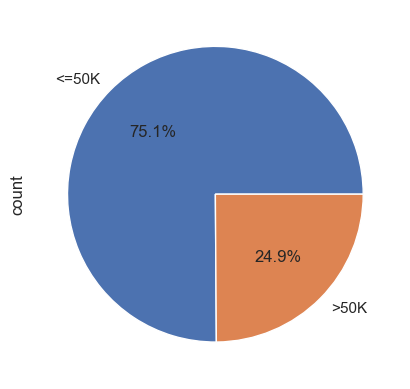

In [292]:
print(df_cleaned['income'].value_counts())
df_cleaned['income'].value_counts().plot.pie(autopct= '%1.1f%%')

In Pie graph, it is clearly showing the individual are in high number who are earning less than 50k. 
Individuals Earning <= $50K: 22,633
Individuals Earning > $50K: 7,506
Here's a detailed analysis:

Socio-Economic Implications
Majority Lower-Income Group: A significant majority of the population, represented by 22,633 individuals, earns $50K or less. This suggests that the predominant economic bracket in this dataset is at or below what might be considered a middle-income level in many developed countries.

Smaller High-Income Group: The group earning over $50K, comprising 7,506 individuals, represents a smaller segment. This indicates that higher earners are less common in this dataset.

**Age Distribution**
"What is the distribution of ages among individuals in the Adult Census

Text(0, 0.5, 'count')

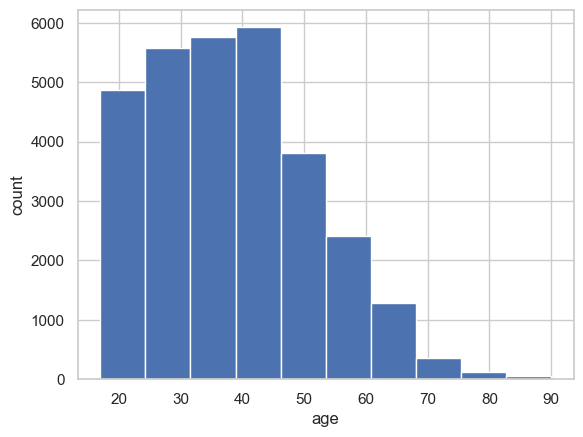

In [293]:
df_cleaned['age'].hist()
plt.xlabel('age')
plt.ylabel('count')

A significant number of individuals in the age range of 25 to 50 are earning a substantial income. People within the 25 to 50 age bracket are often at the most active stage of their careers. They are likely to have completed their education and have significant work experience, leading to potentially higher earning capacities compared to younger or older groups.

# Analytic Question 3 income classification with respect to age

What are the income levels ('<=50K' and '>50K') across different age groups,

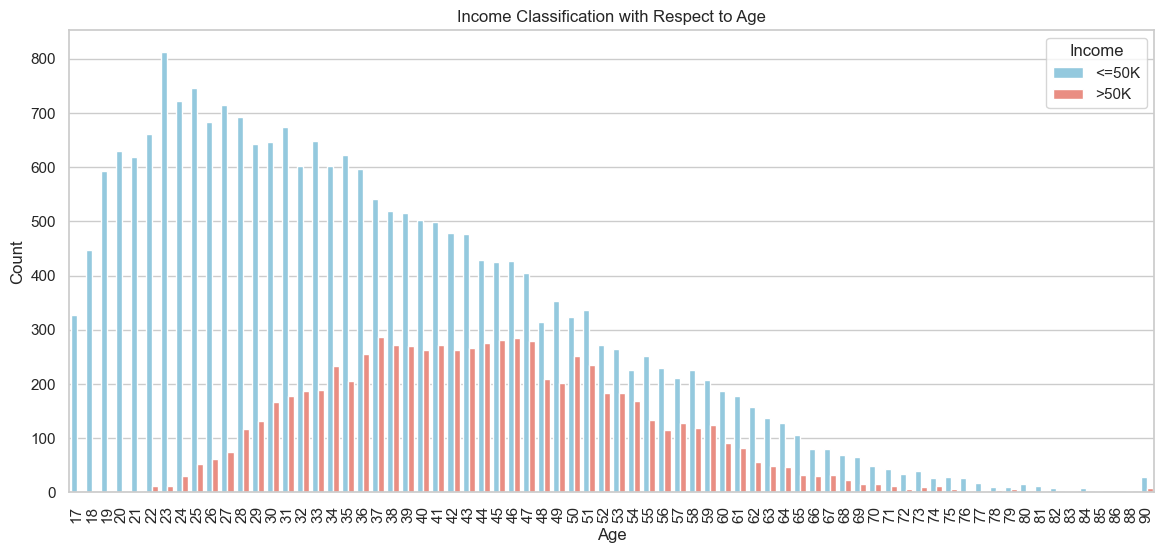

In [294]:
plt.figure(figsize=(14, 6))

sns.countplot(x='age', hue='income', data=df_cleaned, palette={"<=50K": "skyblue", ">50K": "salmon"})

plt.title('Income Classification with Respect to Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Income')
plt.xticks(rotation=90)
plt.show()

Dominant Younger Population: There is a large number of individuals in their early working years (ages approximately from 20 to 30) who fall into the <=50K income bracket.

Peak Earning Ages: The chart suggests a peak in the number of individuals earning >50K in the age ranges commonly associated with mid-career stages (roughly 30 to 50 years of age).

Income Disparity with Age: There's a noticeable disparity between the number of individuals in the two income categories, with fewer individuals earning >50K across all ages. However, the proportion of individuals earning >50K relative to those earning <=50K appears to increase with age until a certain point before it starts to decrease, likely as individuals retire or reduce their working hours.

Decrease in Higher Income Earners After Retirement Age: There is a sharp decline in the number of higher income earners (>50K) past the typical retirement age, which is generally around 65.


**Capital-gain Distribution**

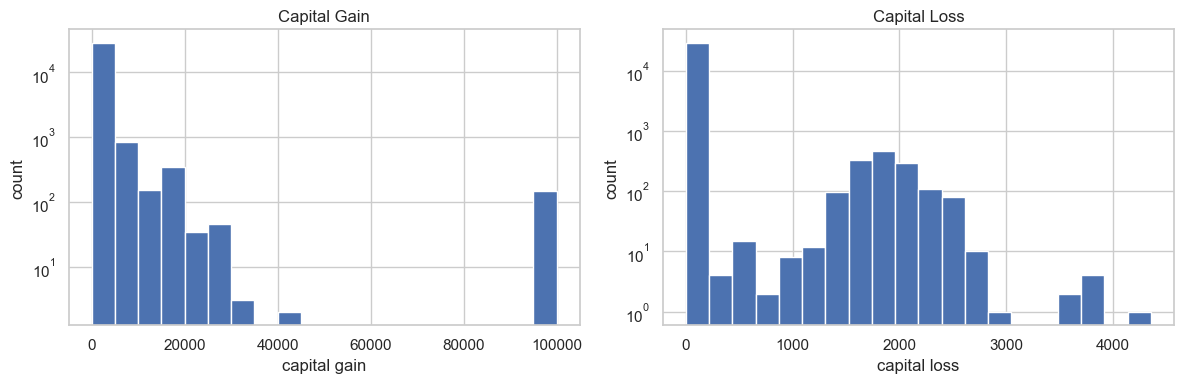

In [295]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Create a 1x2 grid of subplots

# First subplot (axes[0])
df_cleaned['capital.gain'].hist(ax=axes[0], bins=20)
axes[0].set_title('Capital Gain')
axes[0].set_xlabel('capital gain')
axes[0].set_ylabel('count')
axes[0].set_yscale('log')  # Set y-axis to logarithmic scale

# Second subplot (axes[1])
df_cleaned['capital.loss'].hist(ax=axes[1], bins=20)
axes[1].set_title('Capital Loss')
axes[1].set_xlabel('capital loss')
axes[1].set_ylabel('count')
axes[1].set_yscale('log')  # Set y-axis to logarithmic scale

plt.tight_layout()

Both histograms are right-skewed, which is common in financial data, where a large number of individuals have low capital gains or losses, and few have high capital gains or losses.
The data may imply that within this adult income dataset, significant capital gains or losses are not typical for most individuals. This might be reflective of the risk aversion of the general population, or it could indicate a lack of capital investment opportunities or participation.

# Analytics question 4- hours-per-week Distribution*
How is the distribution of hours worked per week among individuals in the dataset

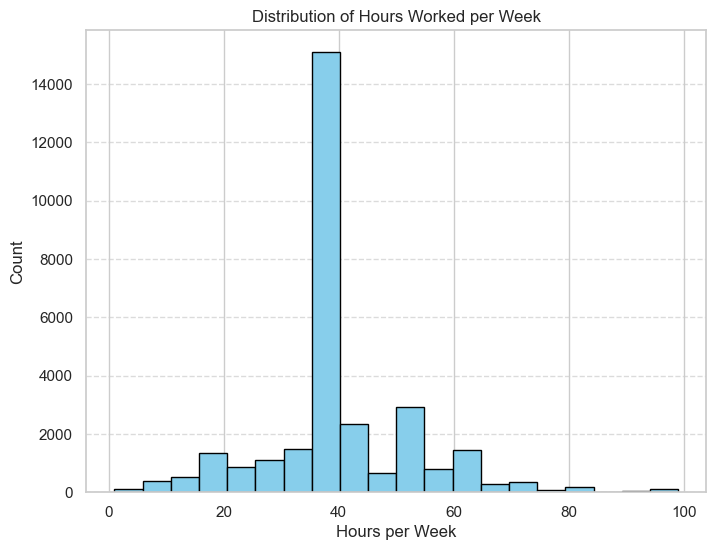

In [296]:
plt.figure(figsize=(8, 6))
plt.hist(df_cleaned['hours.per.week'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Hours Worked per Week')
plt.xlabel('Hours per Week')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

So from graph we can see that hours per week is seems like slightly normally distrubuted with max count for work hourk 35-40 with count around 18000
There are also few people who works 80-100 hours per week and some less than 20 which is unusual.



# Analytic question 5-Workclass Distribution**
What is the distribution of work classes among individuals in the dataset

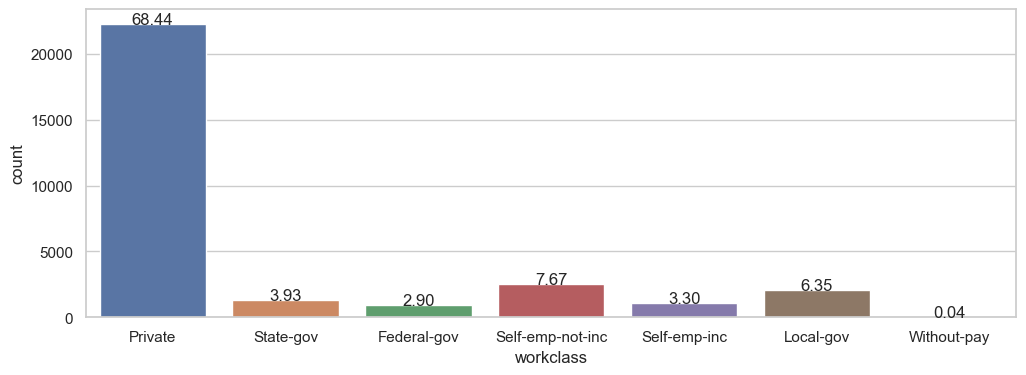

In [297]:
plt.figure(figsize=(12,4))

total = float(len(df['income']))

a = sns.countplot(x='workclass',data=df_cleaned)

for f in a.patches:
    height = f.get_height()
    a.text(f.get_x() + f.get_width()/2., height+3, '{:1.2f}'.format((height/total)*100),ha="center")

Most of them are form private workclass with around 74% and rest all have less contribution compare to private with without-pay as least count of around 0.05% of total count.The chart indicates that the private sector is the predominant employer for individuals within this dataset, which is consistent with general employment trends where the private sector often employs more individuals than the public sector. Self-employment categories together make up just over 10% of the total, while government (state, federal, and local combined) accounts for a smaller but significant portion. The "without-pay" category is very small, suggesting it is not a common workclass among the individuals represented in the dataset.



# Analytic Question - **marital-status Distribution:**
What is the distribution of martial status disturbation among individuals in the dataset

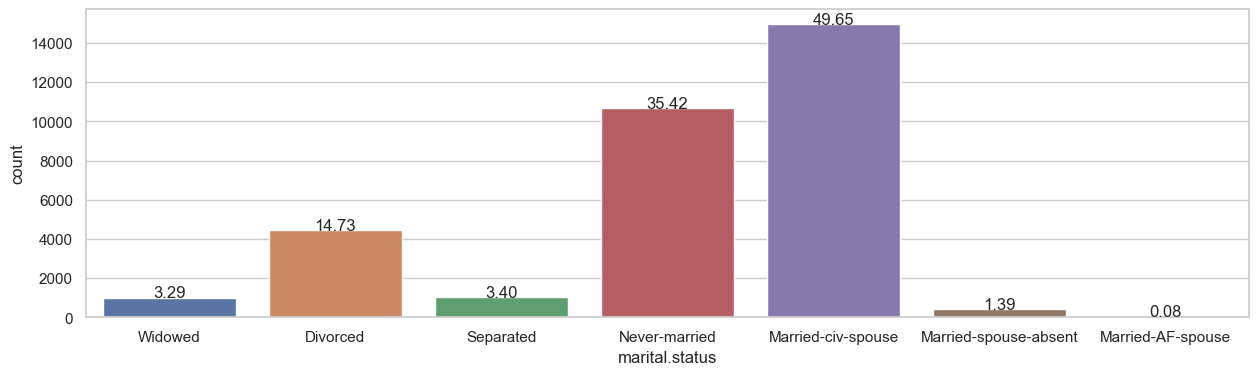

In [298]:
plt.figure(figsize=(15,4))
total = float(len(df_cleaned) )
a = sns.countplot(x="marital.status", data=df)
for p in a.patches:
    height = p.get_height()
    a.text(p.get_x()+p.get_width()/2.,
            height + 3,'{:1.2f}'.format((height/total)*100),ha="center")

Married-civ-spouse has maximum number of samples. Married-AF-spouse has minimum number of obs.



**Analytic question*
What is the distribution of relationship among individuals in the dataset

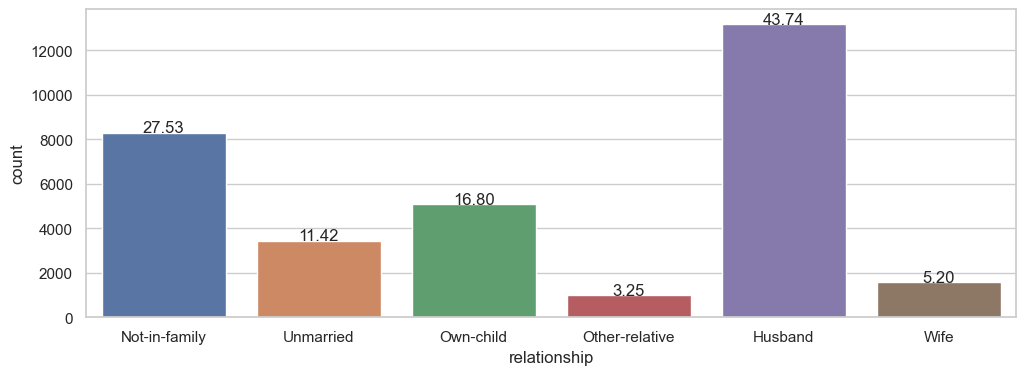

In [299]:
plt.figure(figsize=(12,4))
total = float(len(df_cleaned) )
a = sns.countplot(x="relationship", data=df)
for p in a.patches:
    height = p.get_height()
    a.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.2f}'.format((height/total)*100),ha="center")

In income there is 2 group,group1(who earns more than 50k) 24.90% belong to income and group2(who earns less than 50k) 75.10% belong to income



**Bivariate Analysis**

**Boxplot(Age relationship with income):**

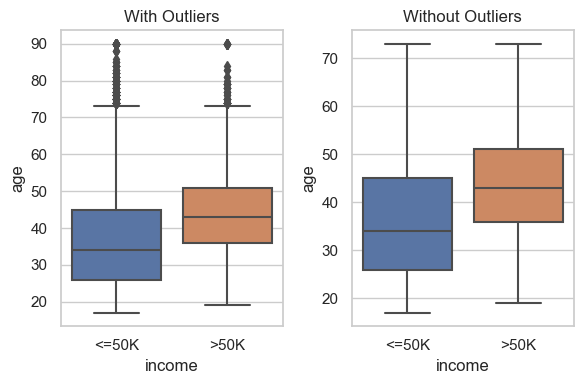

In [300]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Without Error
plt.subplot(1, 2, 1)  # Create the first subplot
sns.boxplot(x='income', y='age', data=df_cleaned).set_title('With Outliers')

# With Error
plt.subplot(1, 2, 2)  # Create the second subplot
sns.boxplot(x='income', y='age', data=df_cleaned, showfliers=False).set_title('Without Outliers')

plt.tight_layout()  # Adjust layout to prevent overlap

we can observe that the median age for people earning more than 50k is significantly greater than the median of people earning less than 50k. So, older people are more likely to earn more than $50k a year as compared to their younger counterparts.

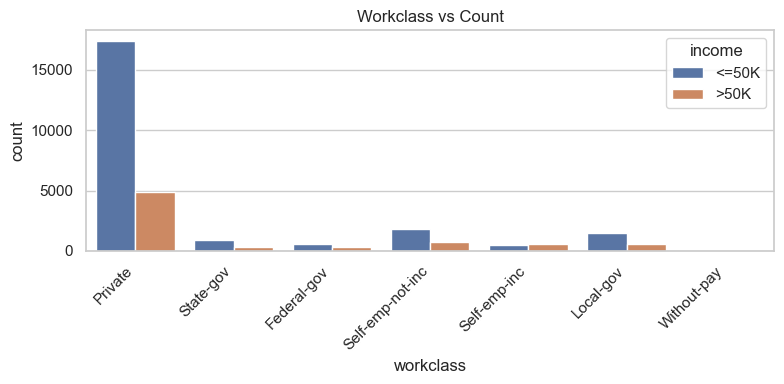

In [301]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x='workclass', hue='income', data=df_cleaned)
ax.set_title("Workclass vs Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Adjust rotation and alignment
plt.tight_layout()
plt.show()

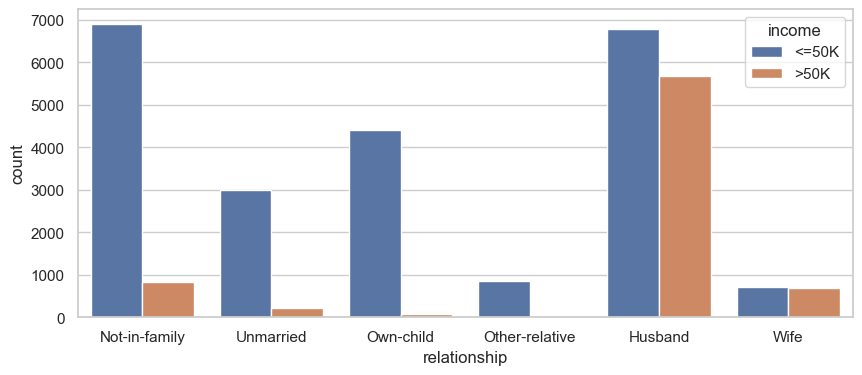

In [302]:
plt.figure(figsize=(10,4))
sns.countplot(x="relationship", hue="income",data=df_cleaned);

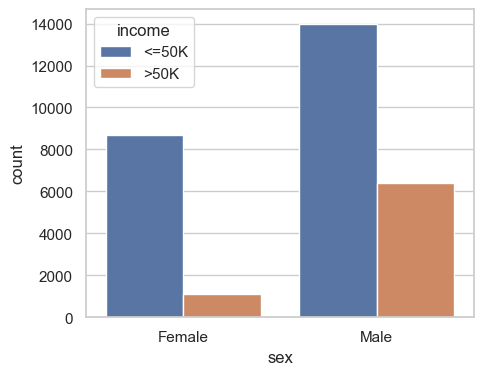

In [303]:
plt.figure(figsize=(5,4))
sns.countplot(x="sex", hue="income",data=df_cleaned);

Which countries,  have the highest number of individuals earning above $50K according to the data presented, and what could be the possible reasons for this distribution?

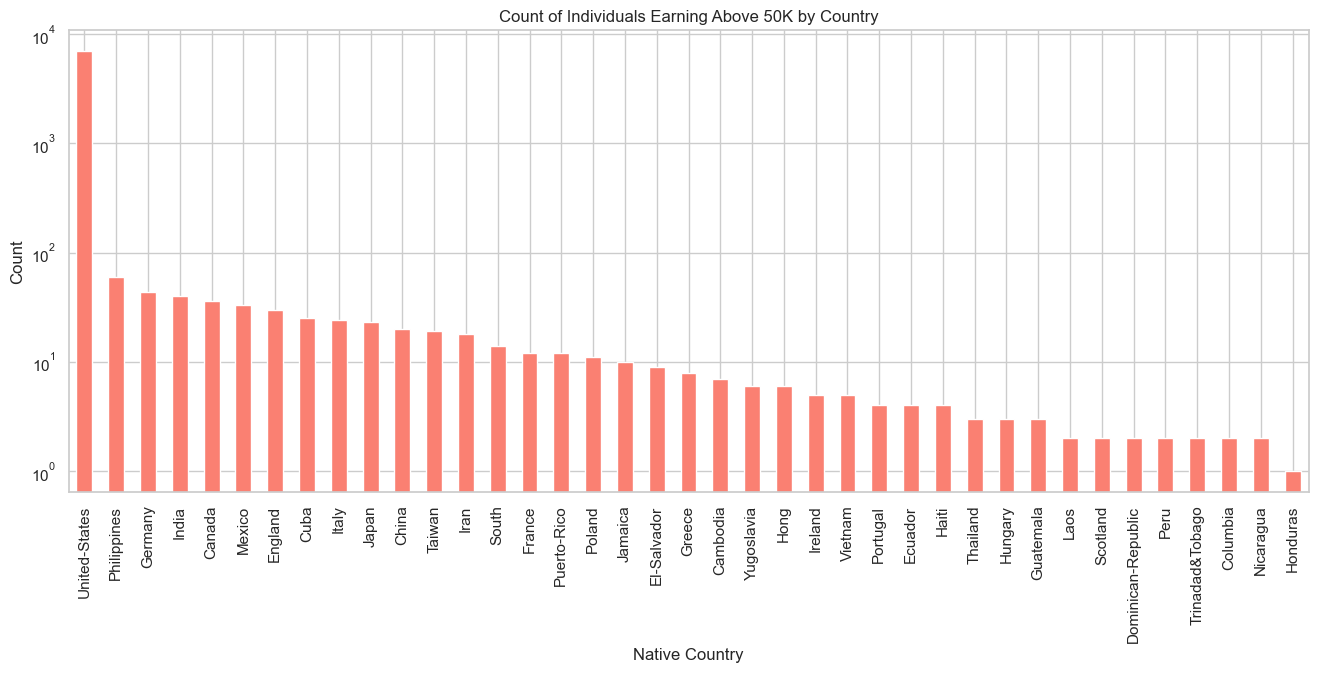

In [304]:
# Grouping data by native country and income, then calculating the count of individuals with income >50K
income_by_country = df_cleaned[df_cleaned['income'] == '>50K'].groupby('native.country')['income'].count().sort_values(ascending=False)

# Plotting count of individuals earning >50K for each country
plt.figure(figsize=(16, 6))
income_by_country.plot(kind='bar', color='salmon')
plt.title('Count of Individuals Earning Above 50K by Country')
plt.xlabel('Native Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.yscale('log')
plt.show()

The United States has the highest count of individuals earning more than $50K by a significant margin. This is expected as the dataset commonly known as the Adult dataset (also referred to as the "census income" dataset) predominantly contains samples from the United States.

Looking beyond the United States, the next highest counts are for the Philippines, Germany, Canada, and India.

In [305]:
# the top countries where people tend to have higher income levels.

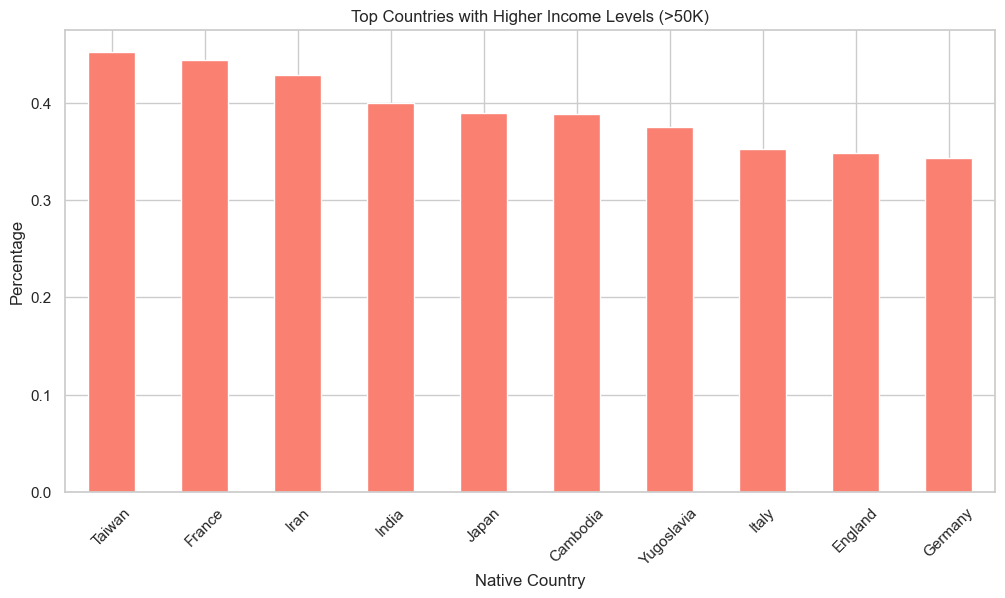

In [306]:
# Grouping data by native country and income, then calculating the count of individuals with income >50K
income_by_country = df_cleaned[df_cleaned['income'] == '>50K'].groupby('native.country')['income'].count().sort_values(ascending=False)


# Calculating percentage of individuals with income >50K by native country
income_by_country = df_cleaned.groupby('native.country')['income'].value_counts(normalize=True).unstack().fillna(0)
income_above_50k = income_by_country['>50K'].sort_values(ascending=False)

# Plotting top countries with the highest percentage of income >50K
plt.figure(figsize=(12, 6))
top_countries = income_above_50k.head(10)
top_countries.plot(kind='bar', color='salmon')
plt.title('Top Countries with Higher Income Levels (>50K)')
plt.xlabel('Native Country')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

In [307]:
Is there a gender disparity in high and low income levels as represented in this dataset?

Object `dataset` not found.


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



<Figure size 1000x600 with 0 Axes>

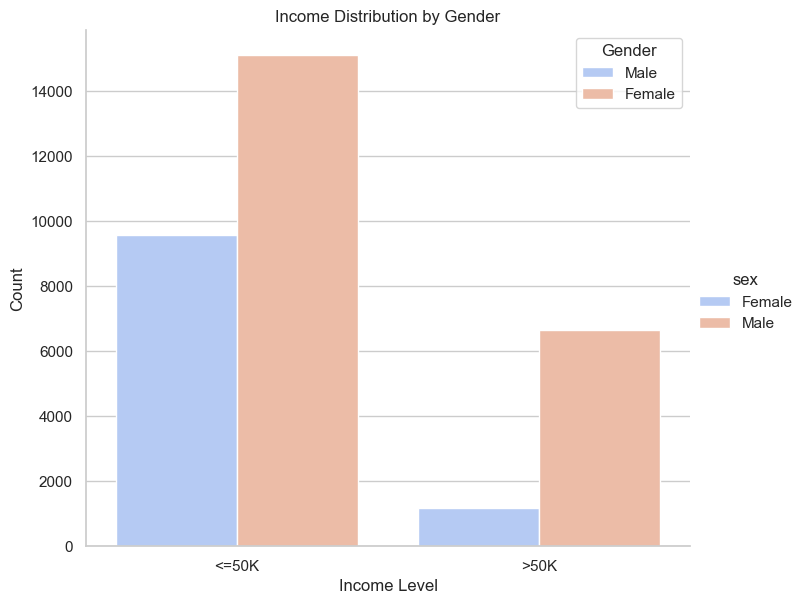

In [308]:
# Visualizing income distribution by gender
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
g = sns.catplot(x='income', hue='sex', data=df, kind='count', palette='coolwarm', height=6, aspect=1.2)
g.ax.set_title('Income Distribution by Gender')
g.ax.set_xlabel('Income Level')
g.ax.set_ylabel('Count')

# Customize legend
legend_labels = ['Male', 'Female']
legend_title = 'Gender'
handles = g._legend_data.values()
g.ax.legend(handles=handles, labels=legend_labels, title=legend_title)



there are more females than males in the lower income level. At the higher income level, the number of individuals for both genders decreases, which is typical as fewer people tend to reach higher income brackets. However, the relative difference in the counts of males and females is smaller at the higher income level compared to the lower income level, indicating that the proportion of females to males is closer to parity in the higher income bracket than in the lower one.

How do the distributions of weekly work hours differ between genders, and what impact do outliers have on the analysis?

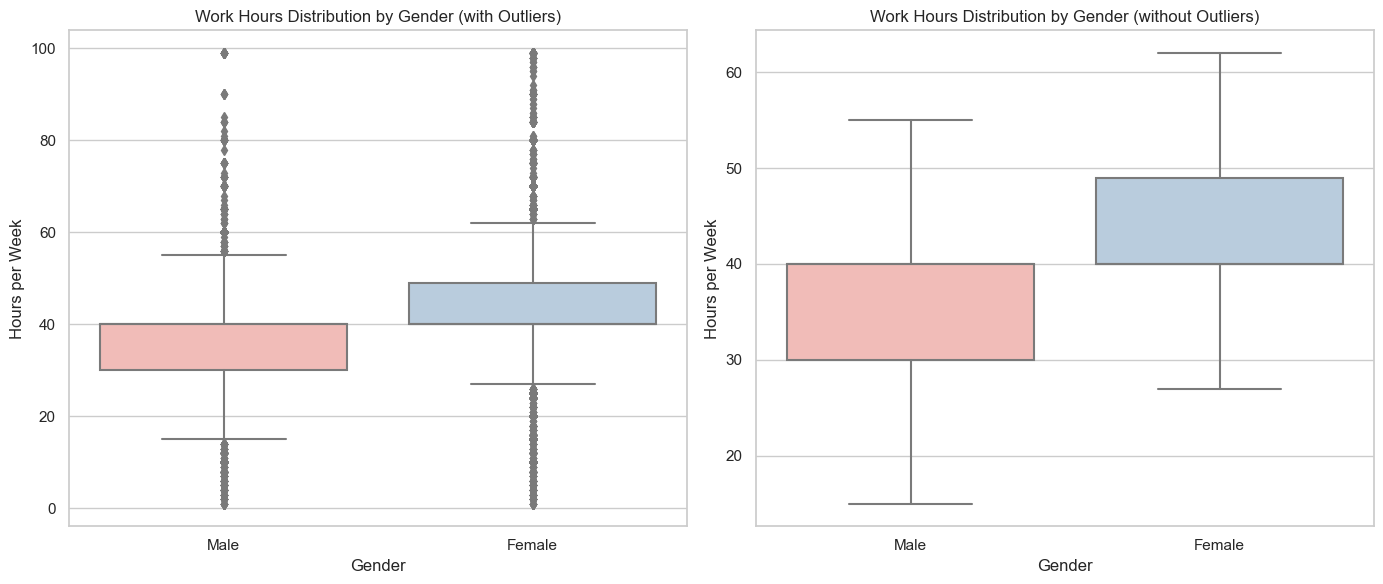

In [309]:

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot with outliers
sns.boxplot(x='sex', y='hours.per.week', data=df, palette='Pastel1', ax=axes[0])
axes[0].set_title('Work Hours Distribution by Gender (with Outliers)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Hours per Week')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Male', 'Female'])

# Plot without outliers
sns.boxplot(x='sex', y='hours.per.week', data=df, showfliers=False, palette='Pastel1', ax=axes[1])
axes[1].set_title('Work Hours Distribution by Gender (without Outliers)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Hours per Week')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Male', 'Female'])

plt.tight_layout()
plt.show()


the distributions tighten, indicating that most males and females work around the standard 40-hour workweek, but there is a slightly higher variability in the number of hours worked by males.
The presence of outliers, particularly in the male distribution, could be indicative of certain professions or roles where long work hours are more common, or it may reflect a difference in overtime or multiple job holdings between genders.

In [310]:
df_cleaned.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [311]:
grouped_df = df_cleaned.groupby(['marital.status', 'occupation', 'relationship', 'sex']).agg({
    'capital.gain': 'sum',
    'capital.loss': 'sum'
}).reset_index()

**Analytic Question--** 
How does capital loss and capital gain differ across various occupations, and is there a notable difference between genders within these occupations?

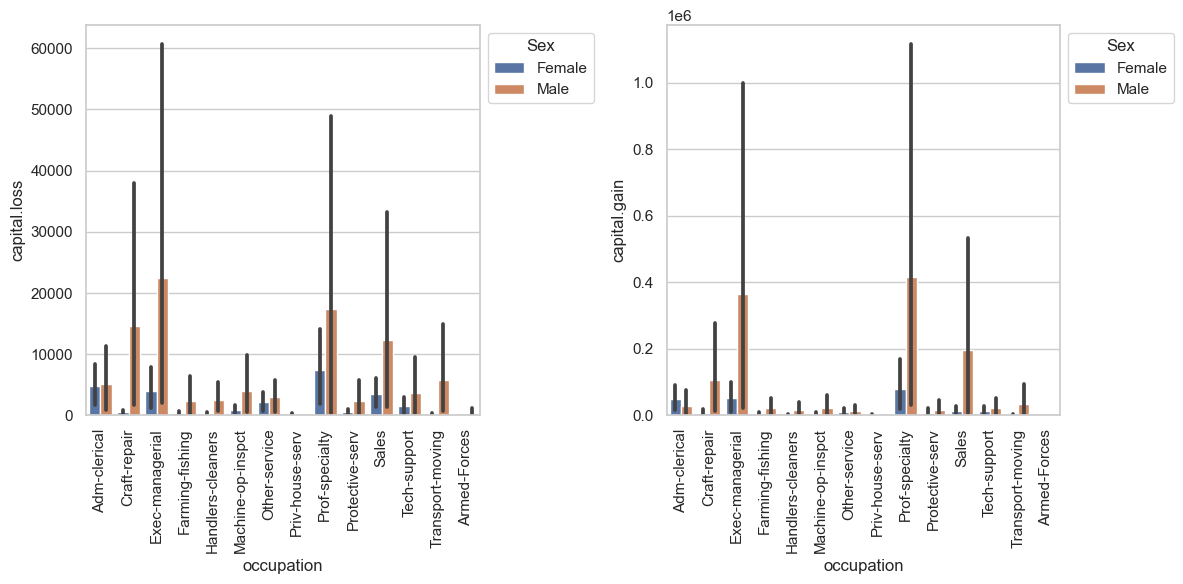

In [312]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
grouped_df = grouped_df  # Replace with your actual DataFrame

# Create the bar plot with hue for capital.gain and capital.loss
sns.barplot(data=grouped_df, x='occupation', y='capital.loss', hue='sex', ax=ax[0])
sns.barplot(data=grouped_df, x='occupation', y='capital.gain', hue='sex', ax=ax[1])

# Rotate x-axis ticks by 90 degrees
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)

# Add legend
ax[0].legend(title='Sex', loc='upper left', bbox_to_anchor=(1, 1))
ax[1].legend(title='Sex', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
# Show the plot
plt.show()

Capital losses are relatively low across most occupations, with occasional outliers indicating higher losses, particularly in "Exec-managerial" and "Prof-specialty" roles.
Males tend to have slightly higher capital losses across various occupations than females.
Capital gains are generally higher than losses, with most gains concentrated at the lower end, but significant gains are present in "Exec-managerial" and "Prof-specialty" occupations for both genders.
Males in "Exec-managerial" roles show marginally higher capital gains than females.
The overall trend indicates that high capital gains or losses are relatively uncommon but are more likely to be reported by individuals in executive or professional specialties. Gender differences in financial outcomes are present but not stark.

How does the relationship status of individuals correlate with the magnitude of capital gains and losses within this dataset?

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Not-in-family'),
  Text(1, 0, 'Other-relative'),
  Text(2, 0, 'Own-child'),
  Text(3, 0, 'Unmarried'),
  Text(4, 0, 'Husband'),
  Text(5, 0, 'Wife')])

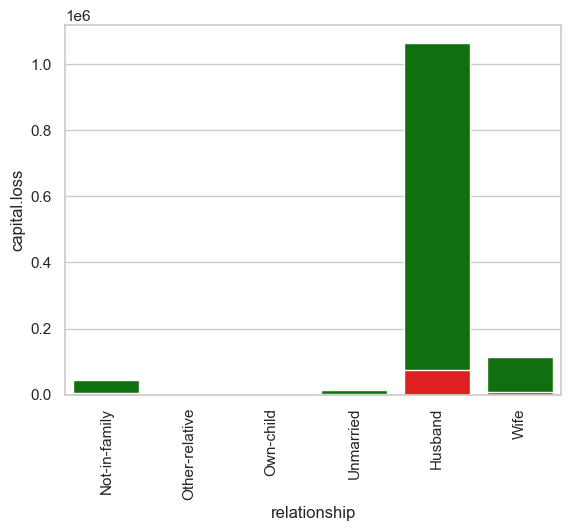

In [313]:
sns.barplot(data=grouped_df, x='relationship', y='capital.gain', errorbar=None, color='green')
sns.barplot(data=grouped_df, x='relationship', y='capital.loss', errorbar=None, color='red')
plt.xticks(rotation=90)

The bar chart provided illustrates the correlation between individuals' relationship status and their reported capital gains and losses. Capital gains are represented in green, and capital losses are in red. The relationship statuses included are 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Husband', and 'Wife'.

From the chart, it is evident that:

'Husbands' have the highest capital gains, as indicated by the towering green bar. This group also has a visible but comparatively smaller amount of capital loss (red).
'Wife' also shows both capital gains and losses, with gains exceeding losses, but both figures are much less than that of 'Husband'.
All other relationship statuses ('Not-in-family', 'Other-relative', 'Own-child', 'Unmarried') have negligible capital gains and losses in comparison to 'Husband' and 'Wife'

In [314]:
df_cleaned['occupation'].unique()

array(['Exec-managerial', 'Machine-op-inspct', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Transport-moving', 'Sales',
       'Craft-repair', 'Farming-fishing', 'Tech-support',
       'Protective-serv', 'Handlers-cleaners', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [315]:
How does the distribution of different occupations compare within two salary ranges, <=50K and >50K, and which occupations are most common in each salary range?

Text(0.5, 1.0, 'Comparison of Occupation with Salary Range')

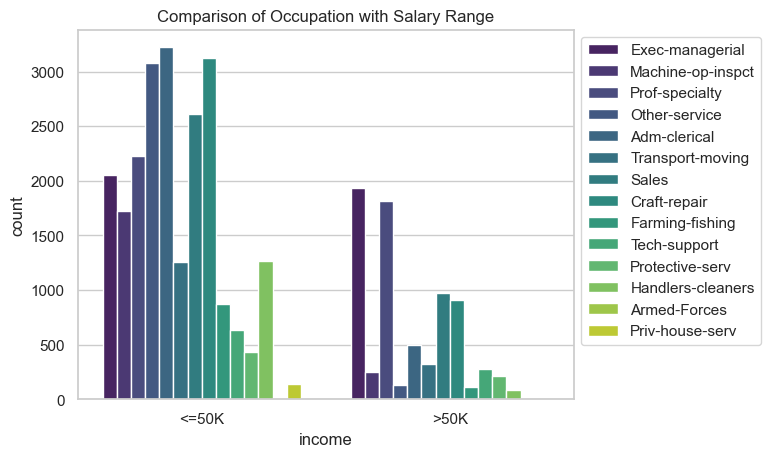

In [316]:
occupation_palette = sns.color_palette("viridis", 14)

# Plot countplot with the custom color palette
sns.countplot(x='income', hue='occupation', data=df_cleaned, palette=occupation_palette)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Comparison of Occupation with Salary Range')


**Analytic Question** How do age and hours worked per week correlate with income levels (<=50K and >50K), and is there a noticeable trend or pattern that differentiates the two income groups in terms of age or hours worked?

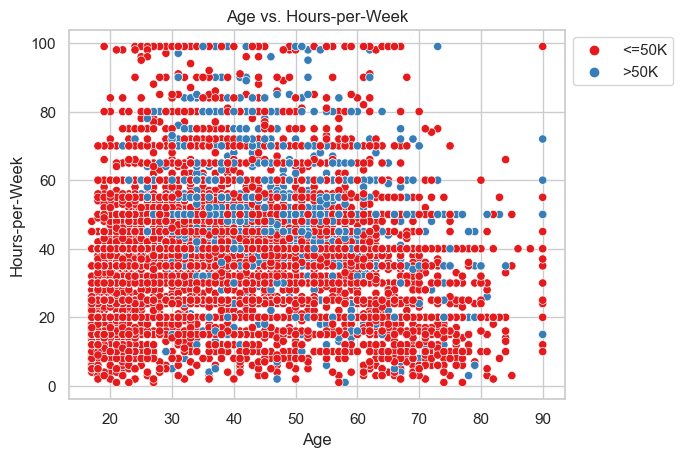

In [317]:
sns.scatterplot(x="age", y="hours.per.week", hue="income", data=df_cleaned, palette="Set1")
plt.title("Age vs. Hours-per-Week")
plt.xlabel("Age")
plt.ylabel("Hours-per-Week")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

education
10th             820
11th            1048
12th             377
1st-4th          151
5th-6th          288
7th-8th          557
9th              455
Assoc-acdm      1008
Assoc-voc       1307
Bachelors       5044
Doctorate        375
HS-grad         9840
Masters         1627
Preschool         45
Prof-school      542
Some-college    6678
Name: count, dtype: int64


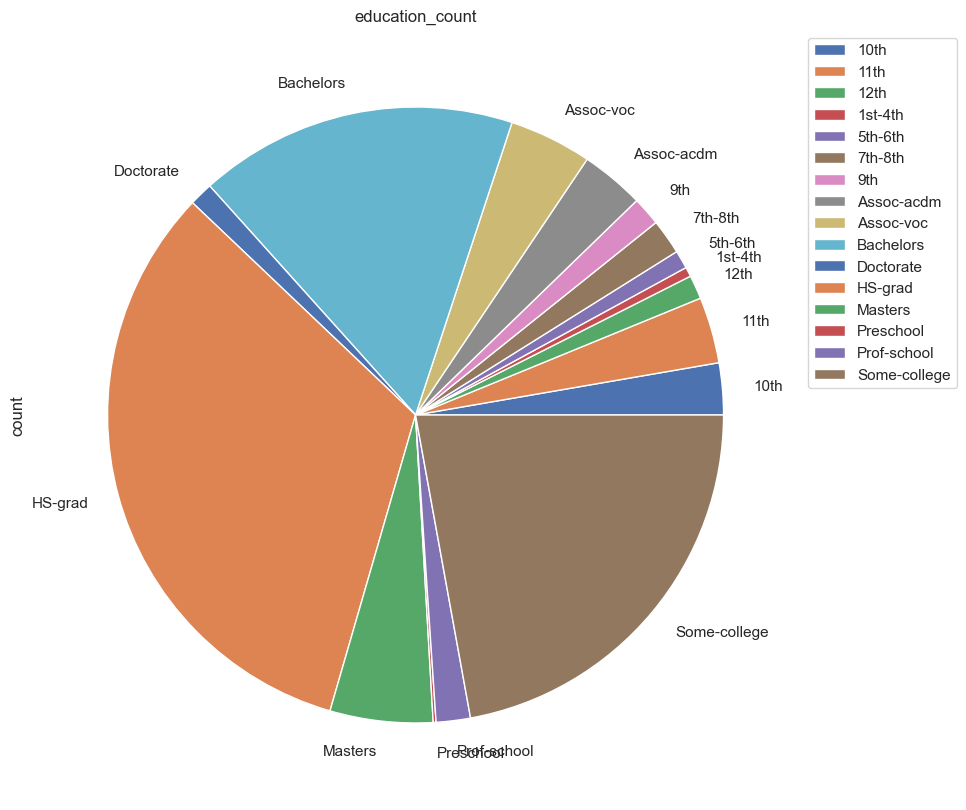

In [318]:
counts=df_cleaned['education'].value_counts().sort_index()
print(counts)
counts.plot(kind='pie',title='education_count',figsize=(11,10))
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


The education level in the dataset varies, with the majority having completed 'HS-grad' (High School Graduation) at 10,501 individuals. 'Bachelors' is the second most common education level at 5,355 individuals, followed by 'Some-college' with 7,291 individuals. Higher education levels like 'Masters,' 'Assoc-voc,' and 'Assoc-acdm' have fewer individuals represented.

**Analytic Question** How do the distributions of hours worked per week vary between males and females within two different income brackets, <=50K and >50K?

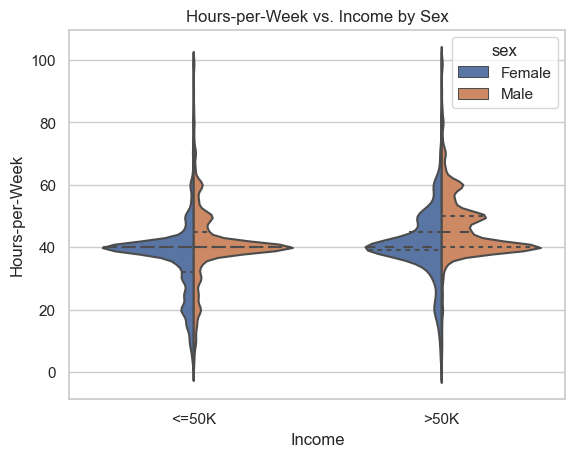

In [319]:
sns.violinplot(x="income", y="hours.per.week", hue="sex", data=df_cleaned, split=True, inner="quart")
plt.title("Hours-per-Week vs. Income by Sex")
plt.xlabel("Income")
plt.ylabel("Hours-per-Week")
plt.show()

**Analytic Question** What is the distribution of occupations among a given population, and which occupations have the highest and lowest representation?

education
10th             820
11th            1048
12th             377
1st-4th          151
5th-6th          288
7th-8th          557
9th              455
Assoc-acdm      1008
Assoc-voc       1307
Bachelors       5044
Doctorate        375
HS-grad         9840
Masters         1627
Preschool         45
Prof-school      542
Some-college    6678
Name: count, dtype: int64


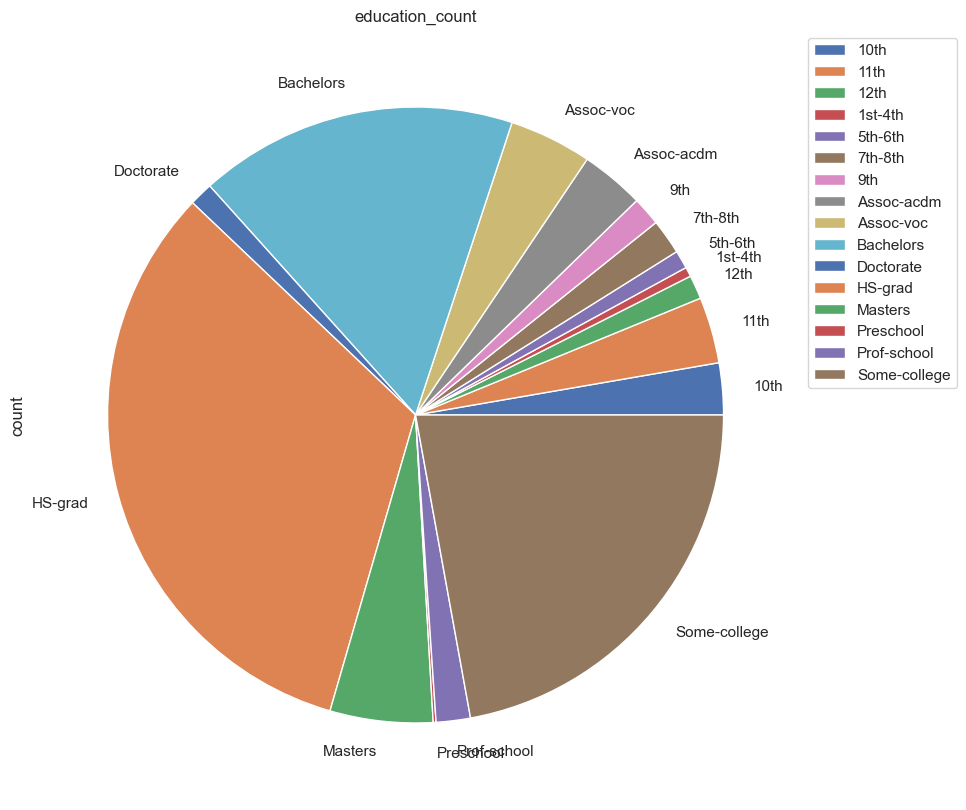

In [320]:
counts=df_cleaned['education'].value_counts().sort_index()
print(counts)
counts.plot(kind='pie',title='education_count',figsize=(11,10))
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


professional specialties and craft-related repairs are the most common occupations, while private house services and military occupations are the least represented in this data set.

**Analytic Question:** Is there a correlation between the number of years of education completed and earning a higher income (> $50K), and what are the key educational milestones that differentiate income levels according to this distribution?



**Analytic Question** Which occupations are associated with the highest capital gains, and how do capital gains vary across different occupations?

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Adm-clerical'),
  Text(1, 0, 'Craft-repair'),
  Text(2, 0, 'Exec-managerial'),
  Text(3, 0, 'Farming-fishing'),
  Text(4, 0, 'Handlers-cleaners'),
  Text(5, 0, 'Machine-op-inspct'),
  Text(6, 0, 'Other-service'),
  Text(7, 0, 'Priv-house-serv'),
  Text(8, 0, 'Prof-specialty'),
  Text(9, 0, 'Protective-serv'),
  Text(10, 0, 'Sales'),
  Text(11, 0, 'Tech-support'),
  Text(12, 0, 'Transport-moving'),
  Text(13, 0, 'Armed-Forces')])

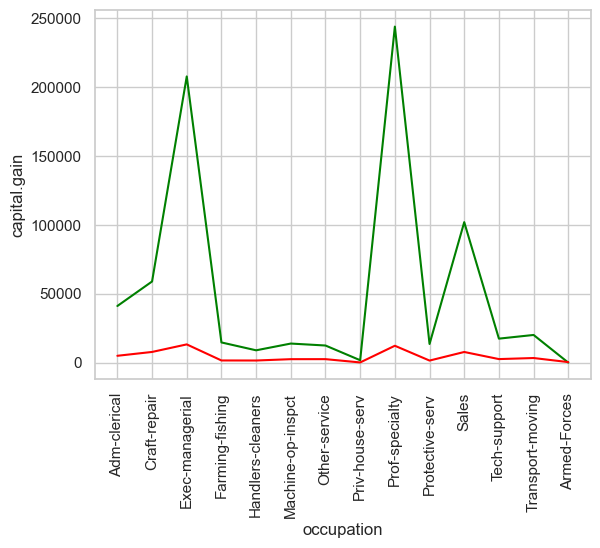

In [321]:
sns.lineplot(data=grouped_df, x='occupation', y='capital.gain', errorbar=None, color='green')
sns.lineplot(data=grouped_df, x='occupation', y='capital.loss', errorbar=None, color='red')

plt.xticks(rotation=90)

The occupation "Exec-managerial" has the highest peak, indicating that individuals in this occupation have the highest capital gains among the occupations listed.

"Prof-specialty" also shows a significant peak, suggesting that this occupation also tends to be associated with high capital gains.

Other occupations, such as "Sales" and "Transport-moving," show smaller peaks, implying lower but notable capital gains compared to the first two occupations.

The rest of the occupations, including "Adm-clerical," "Craft-repair," "Farming-fishing," and others, show very low to almost no capital gains, as indicated by the lines close to the bottom of the y-axis.

In conclusion, the chart suggests that capital gains are significantly higher in "Exec-managerial" and "Prof-specialty" occupations, with other occupations showing much lower capital gains. This could indicate that certain professional roles offer more opportunities for investments or activities that lead to capital gains.

Correlation

Text(0.5, 1.0, 'Correlation Matrix')

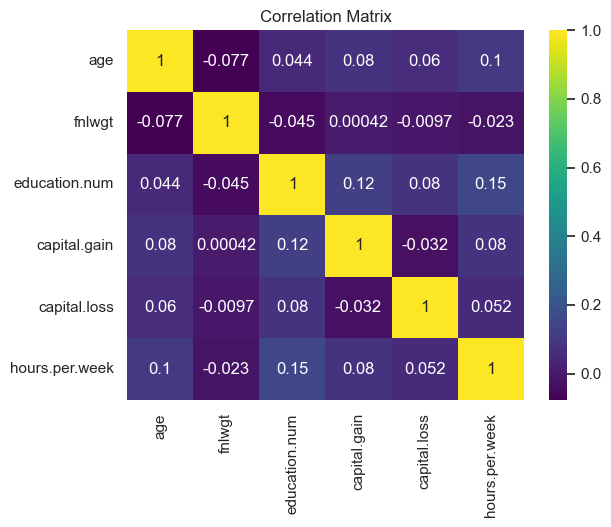

In [322]:
numeric_df = df_cleaned.select_dtypes(include=[np.number])

# Now you can compute the correlation matrix
ax = sns.heatmap(numeric_df.corr(method="pearson"), annot=True, cmap='viridis')
ax.set_title("Correlation Matrix")


The heatmap of the correlation matrix indicates weak correlations between the variables analyzed, with no strong linear relationships evident. Age and 'fnlwgt' have negligible correlations with other factors, suggesting limited predictive value. A weak positive correlation exists between education years and weekly work hours, hinting at a possible trend where higher education might lead to working more hours. Capital gains and losses do not show significant correlations with the demographic or work-related variables. Overall, the variables in this dataset appear to have little linear association with one another.

In [323]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [324]:
X = df.drop('income', axis = 1)
y = df['income']
# standardizing the dataframe
X = StandardScaler().fit_transform(X)
X.shape

(32561, 14)

**Data splitting**

We split the provided data set in 80:20 for training and testing. In ML, we split the data to evaluate the performance of our models accurately. The main reason for splitting data into training and testing sets is to train our model on a subset of data and test its performance on unseen data.

By using a separate testing set, we can determine whether our model is overfitting or underfitting. Overfitting occurs when the model performs well on the training data but poorly on the testing data, while underfitting occurs when the model does not capture the underlying patterns in the data and performs poorly on both training and testing data.

Splitting data allows us to optimize our model's parameters on the training data and evaluate its performance on the testing data, which is representative of the real-world data. This process helps us to build models that generalize well to new, unseen data and provide accurate predictions or classifications.

In [325]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=43)

In [326]:
modelLG = LogisticRegression()
modelLG.fit(x_train, y_train)
y_predict = modelLG.predict(x_test)
print('Accuracy=',accuracy_score(y_test, y_predict))

Accuracy= 0.8255796100107478


In [327]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4976
           1       0.70      0.46      0.55      1537

    accuracy                           0.83      6513
   macro avg       0.77      0.70      0.72      6513
weighted avg       0.81      0.83      0.81      6513



**Precision:**

 Precision is a measure of how accurate a model’s positive predictions are. It is defined as the ratio of true positive predictions to the total number of positive predictions made by the model

** Accuracy:**
  Accuracy is used to measure the performance of the model. It is the ratio of Total correct instances to the total instances.

  **Recall:**
  
   Recall measures the effectiveness of a classification model in identifying all relevant instances from a dataset. It is the ratio of the number of true positive (TP) instances to the sum of true positive and false negative (FN) instances.

  ** F1-Score**:
  
   F1-score is used to evaluate the overall performance of a classification model. It is the harmonic mean of precision and recall,



**Confusion Matrix**

A confusion matrix is a matrix that summarizes the performance of a machine learning model on a set of test data. It is often used to measure the performance of classification models, which aim to predict a categorical label for each input instance. The matrix displays the number of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) produced by the model on the test data.

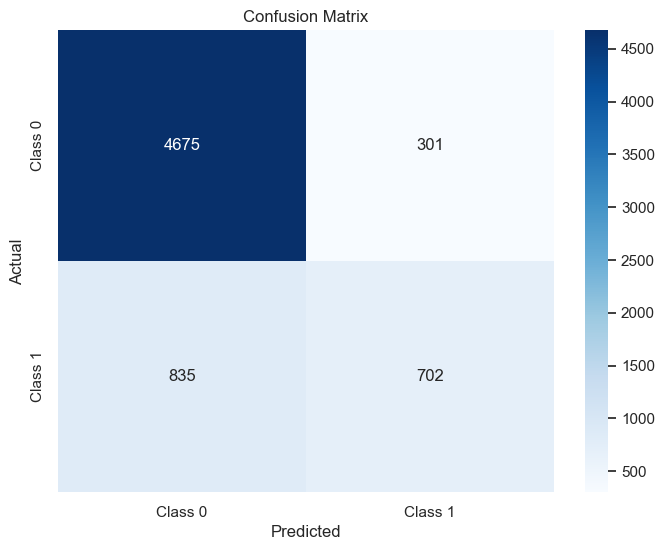

In [328]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [329]:

accuracy = accuracy_score(y_test, y_predict)
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1_score = f1_score(y_test, y_predict)


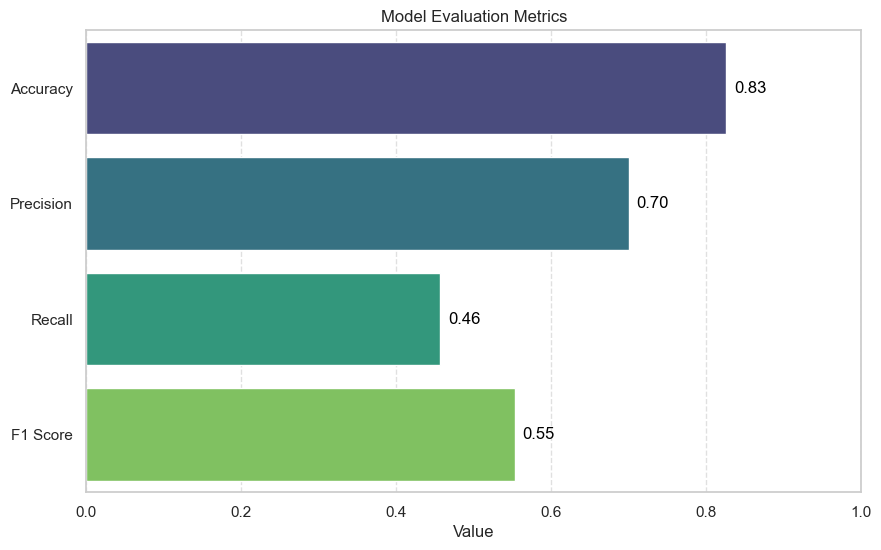

In [330]:
# Create a bar plot to visualize the metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1_score]

plt.figure(figsize=(10, 6))
sns.barplot(x=values, y=metrics, palette='viridis')
plt.title('Model Evaluation Metrics')
plt.xlabel('Value')
plt.xlim(0, 1)  # Adjust the x-axis limits if needed
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Annotate the values on the bars
for i, v in enumerate(values):
    plt.text(v + 0.01, i, f'{v:.2f}', color='black', va='center')

plt.show()

3. Logistic Regression Model
A logistic regression model was trained with an accuracy of approximately 82.56%. This model is a good baseline for binary classification problems.

Classification Report
The classification report for the logistic regression model shows several performance metrics:

Precision: The model has a precision of 0.85 for class '0' and 0.70 for class '1', indicating it's more precise in predicting class '0'.
Recall: Recall is higher for class '0' (0.94) compared to class '1' (0.46), suggesting the model is better at identifying class '0' instances.
F1-Score: The F1 score, which balances precision and recall, is higher for class '0' (0.89) than for class '1' (0.55).
Confusion Matrix
The confusion matrix for logistic regression was visualized using a heatmap, showing the number of true positive, false positive, false negative, and true negative predictions.

In [331]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming X and y are defined (features and target variable)
# Standardizing the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the standardized data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8, random_state=43)

# Initializing and training a Support Vector Machine Classifier
svm_classifier = SVC(kernel='rbf', random_state=42)  # 'rbf' kernel is radial basis function
svm_classifier.fit(X_train, y_train)

# Predicting on the test set
y_pred_svm = svm_classifier.predict(X_test)

# Calculating accuracy and classification report for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy:', accuracy_svm)

print('SVM Classification Report:')
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8498387839705205
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      4976
           1       0.74      0.57      0.64      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513



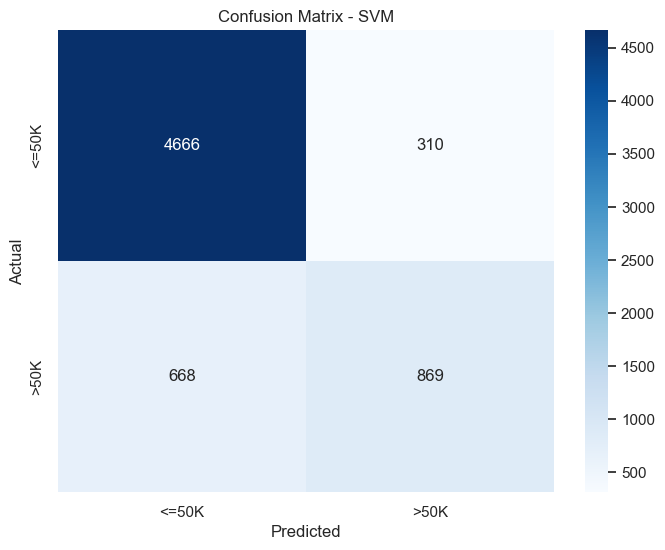

In [332]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix for SVM
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, cmap='Blues', fmt='d', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [333]:
4. Support Vector Machine (SVM) Model
An SVM classifier with RBF kernel was used, achieving an accuracy of approximately 84.98%.

Classification Report for SVM
The SVM shows an improvement over logistic regression with a better balance between precision and recall for both classes.

Confusion Matrix for SVM
The confusion matrix indicates how the SVM model's predictions distribute across the two classes.



SyntaxError: unterminated string literal (detected at line 8) (3653368588.py, line 8)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initializing and training a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predicting on the test set using Random Forest Classifier
y_pred_rf = rf_classifier.predict(X_test)

# Calculating accuracy and classification report for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', accuracy_rf)

print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, cmap='Greens', fmt='d', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


5. Random Forest Classifier
The Random Forest classifier achieved the highest accuracy till now of approximately 86.49%.

Classification Report for Random Forest
This model shows a good balance between precision and recall and a high F1 score, indicating it's effective for both classes.

Confusion Matrix for Random Forest
The confusion matrix visualization shows that Random Forest has a better performance in terms of both false positives and false negatives.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Assuming x_train, x_test, y_train, y_test are defined from the previous split

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(x_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(x_test)

# Calculate accuracy of the Decision Tree Classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy:', accuracy_dt)

# Generate classification report for Decision Tree Classifier
report_dt = classification_report(y_test, y_pred_dt)
print('Decision Tree Classification Report:')
print(report_dt)


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for Decision Tree Classifier
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()


6. Decision Tree Classifier
The Decision Tree achieved an accuracy of approximately 81.33%, which is the lowest among the models.

Classification Report for Decision Tree
The report shows lower precision and recall for class '1', which impacts the F1 score negatively.

Confusion Matrix for Decision Tree
The confusion matrix highlights where the Decision Tree model struggles, especially with false positives and false negatives for class '1'.

7. Accuracy Comparison
Finally, a bar plot was created to compare the accuracy of all models. It clearly shows that the Random Forest model outperforms the others in this dataset.

Summary

Logistic Regression: Baseline model with decent overall performance but lower precision and recall for the minority class.
SVM: Better handling of both classes with the RBF kernel, showing an improved balance between precision and recall.
Random Forest: Best performing model with high accuracy and a better balance of performance metrics across classes.
Decision Tree: The least accurate model, potentially due to overfitting or not capturing the complexity of the data.

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have already calculated accuracies for each model

# List of model names
models = ['Logistic Regression', 'SVM', 'Random Forest', 'Decision Tree']

# List of accuracies corresponding to each model
accuracies = [accuracy_score(y_test, y_predict), accuracy_svm, accuracy_rf, accuracy_dt]  # Replace with your calculated accuracies

print(accuracies)

In [ ]:
import matplotlib.pyplot as plt

# List of model names
models = ['Logistic Regression', 'SVM', 'Random Forest', 'Decision Tree']

# List of accuracies corresponding to each model
accuracies = [accuracy_score(y_test, y_predict), accuracy_svm, accuracy_rf, accuracy_dt]  # Replace with your calculated accuracies

# Plotting the accuracies using a bar plot
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color='skyblue')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit between 0 and 1 for accuracy percentage
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


From the visual representation, all four models perform relatively well, with accuracy rates above 80%. Here's a brief comparison based on the chart:

Logistic Regression: The accuracy appears to be just slightly above 80%. As a linear model, logistic regression is often less complex and may be quicker to train. However, it might not capture complex patterns as well as some other models.

SVM (Support Vector Machine): The SVM model shows a comparable level of accuracy to logistic regression in this instance. SVMs are effective in high-dimensional spaces and with datasets where the number of dimensions exceeds the number of samples.

Random Forest: This model has an accuracy that is marginally higher than the SVM and Logistic Regression. Random Forest is an ensemble method that operates by constructing multiple decision trees at training time and outputting the class that is the mode of the classes of the individual trees. This method is good at handling a variety of data types and tends to perform well on many problems.

Decision Tree: The accuracy of the Decision Tree model is slightly lower than the other models but still remains high. Decision trees are simple to understand and interpret, but they can be prone to overfitting if not properly tuned.

In conclusion, while the Random Forest model shows a slight edge over the others, the differences among the models' accuracies are not substantial in this particular comparison. Each model has its own strengths and may perform differently depending on the complexity and nature of the dataset. Therefore, the choice of model should also consider factors beyond accuracy, such as interpretability, training time, and the ability to handle overfitting.






